# Etapa 2 — Análise Exploratória (EDA)

Usamos o dataset já tratado na Etapa 1. Neste notebook fazemos as estatísticas descritivas, a matriz de correlação (Pearson e Spearman), os histogramas e os boxplots das variáveis numéricas.

In [46]:
import sys
import os
from pathlib import Path

try:
    import google.colab
    _in_colab = True
except ImportError:
    _in_colab = False

_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir()),
    None
)

if _root is None:
    if not _in_colab:
        raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")
    import subprocess
    subprocess.run(
        ['git', 'clone', 'https://github.com/Tassara7/cd2-trabalho.git', '/content/cd2-trabalho'],
        check=True
    )
    _root = Path('/content/cd2-trabalho')
    os.chdir(_root)

_root_str = str(_root.resolve())
if _root_str not in sys.path:
    sys.path.insert(0, _root_str)

## Imports

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import umap.umap_ as umap

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## Carregamento dos dados

Lemos o CSV gerado na Etapa 1 (já limpo e com as variáveis numéricas padronizadas).

In [48]:
csv_path = _root / 'data' / 'processed' / 'restaurants_preprocessed.csv'
df = pd.read_csv(csv_path)

print(f"{df.shape[0]:,} restaurantes × {df.shape[1]} colunas")
df.head()

394,192 restaurantes × 8 colunas


,category,price_range,availableForScheduling,ibge,delivery_fee,delivery_time,minimumOrderValue,rating
0,Marmita,CHEAPEST,0,5300108,-0.65929,-1.25145,-0.56250,-1.09434
1,Açaí,CHEAPEST,0,5300108,0.29218,0.92187,-0.56250,-1.09434
2,Bebidas,MODERATE,0,5300108,1.24366,1.49716,-1.23009,-1.09434
3,Carnes,CHEAPEST,0,5300108,2.31407,1.04971,0.77268,-1.09434
4,Brasileira,CHEAPEST,0,5300108,1.24366,0.73010,0.77268,-1.09434


In [49]:
col_num = ['delivery_fee', 'delivery_time', 'minimumOrderValue', 'rating']
col_cat = ['category', 'price_range', 'availableForScheduling', 'ibge']

## 1. Estatísticas descritivas

As variáveis numéricas já vêm padronizadas da Etapa 1 (StandardScaler), então a média fica próxima de 0 e o desvio próximo de 1. O `describe()` mostra a dispersão relativa de cada uma.

In [50]:
df[col_num].describe()

,delivery_fee,delivery_time,minimumOrderValue,rating
count,394192.00000,394192.00000,394192.00000,394192.00000
mean,0.00000,0.00000,0.00000,0.00000
std,1.00000,1.00000,1.00000,1.00000
min,-1.60839,-2.84947,-1.89768,-1.09434
25%,-0.65691,-0.74008,-0.56250,-1.09434
50%,-0.18117,-0.10087,0.10509,0.61362
75%,0.64899,0.85795,0.77268,0.96682
max,2.55432,3.22302,2.77544,1.09026


In [51]:
print("Top 10 categorias:")
print(df['category'].value_counts().head(10))
print()
print("Faixa de preço:")
print(df['price_range'].value_counts())
print()
print(f"Com agendamento disponível: {df['availableForScheduling'].mean() * 100:.1f}%")
print(f"Municípios distintos (ibge): {df['ibge'].nunique():,}")

Top 10 categorias:
category
Lanches          97395
Brasileira       72032
Doces & Bolos    38916
Pizza            34666
Açaí             21924
Marmita          16389
Bebidas          12616
Japonesa         12539
Saudável          9562
Salgados          9478
Name: count, dtype: int64

Faixa de preço:
price_range
CHEAPEST          287603
MODERATE           42996
CHEAP              42235
EXPENSIVE          14294
MOST_EXPENSIVE      7064
Name: count, dtype: int64

Com agendamento disponível: 0.4%
Municípios distintos (ibge): 1,448


## 2. Matriz de correlação (Pearson e Spearman)

Pearson mede relação linear; Spearman mede relação por postos (monotônica). Comparar os dois ajuda a ver se a relação é linear ou só crescente/decrescente.

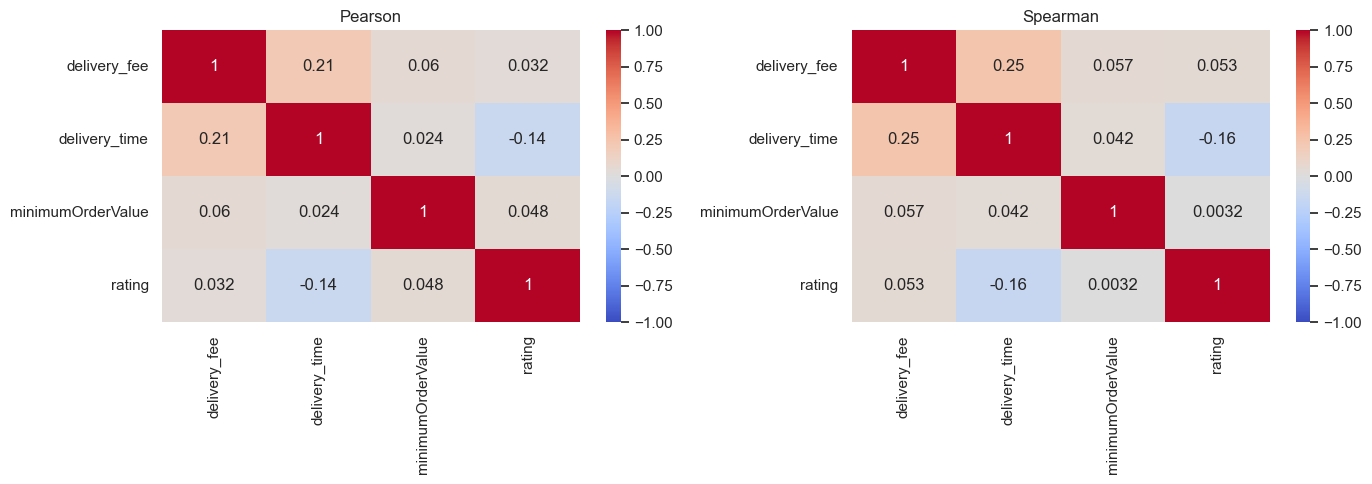

In [52]:
corr_p = df[col_num].corr(method='pearson')
corr_s = df[col_num].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_p, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson')
sns.heatmap(corr_s, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman')
plt.tight_layout()
plt.show()

## 3. Histogramas

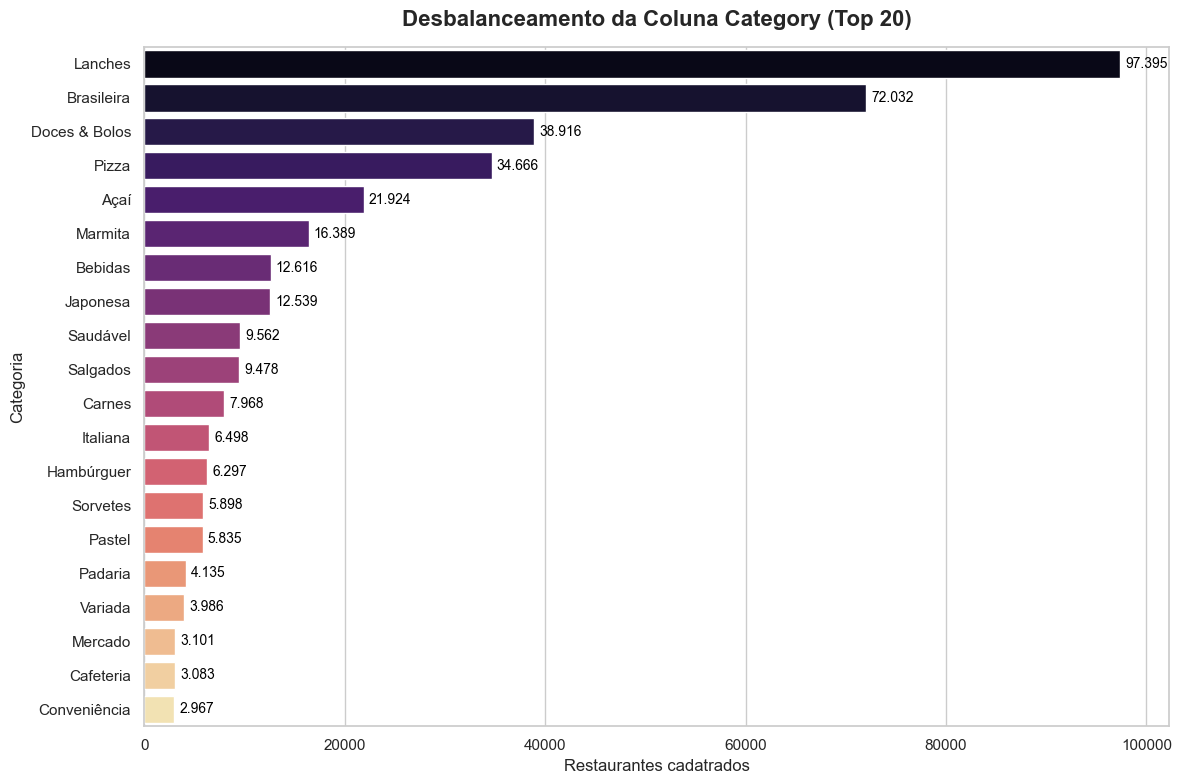

In [53]:
# Plotando a distribuição de categorias:
top_20_categorias = df['category'].value_counts().nlargest(20)
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=top_20_categorias.values,
    y=top_20_categorias.index,
    hue=top_20_categorias.index,
    palette="magma",
    legend=False
)

plt.title('Desbalanceamento da Coluna Category (Top 20)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Restaurantes cadatrados', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

for i, v in enumerate(top_20_categorias.values):
    ax.text(v + 500, i, f"{v:,}".replace(',', '.'), color='black', va='center', fontsize=10)

plt.tight_layout()

plt.show()

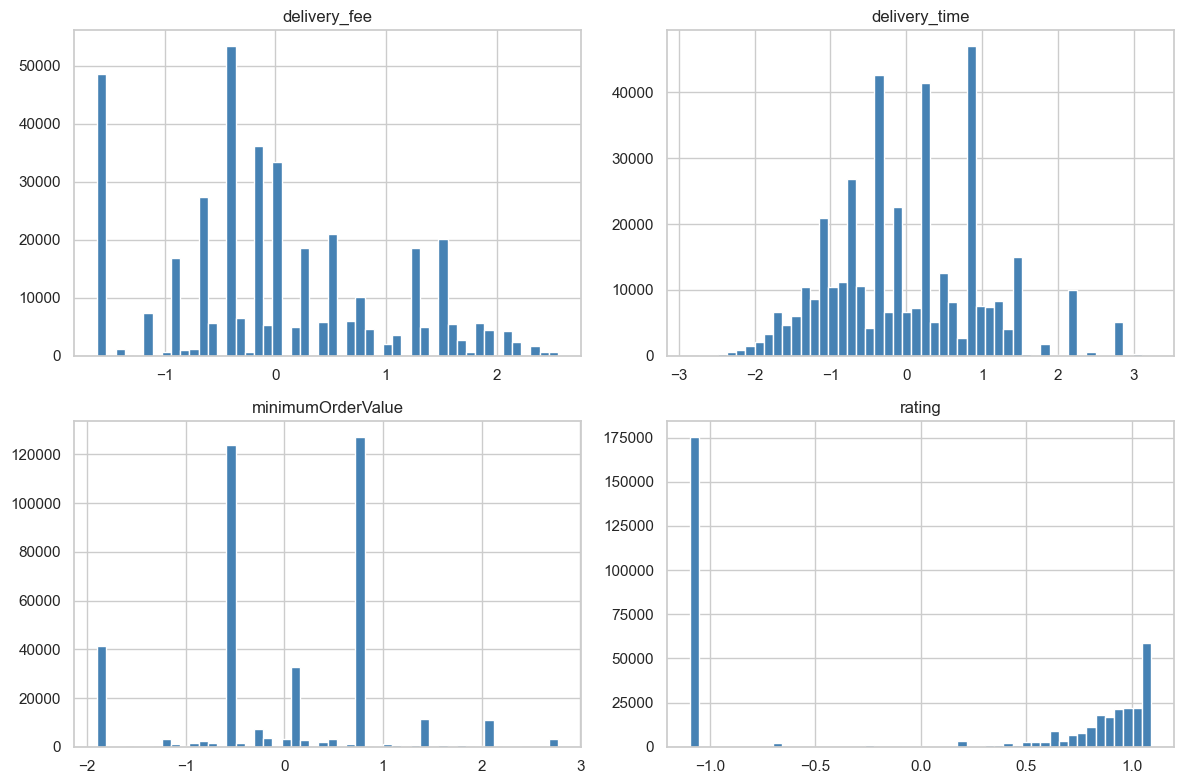

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), col_num):
    ax.hist(df[col], bins=50, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Boxplots

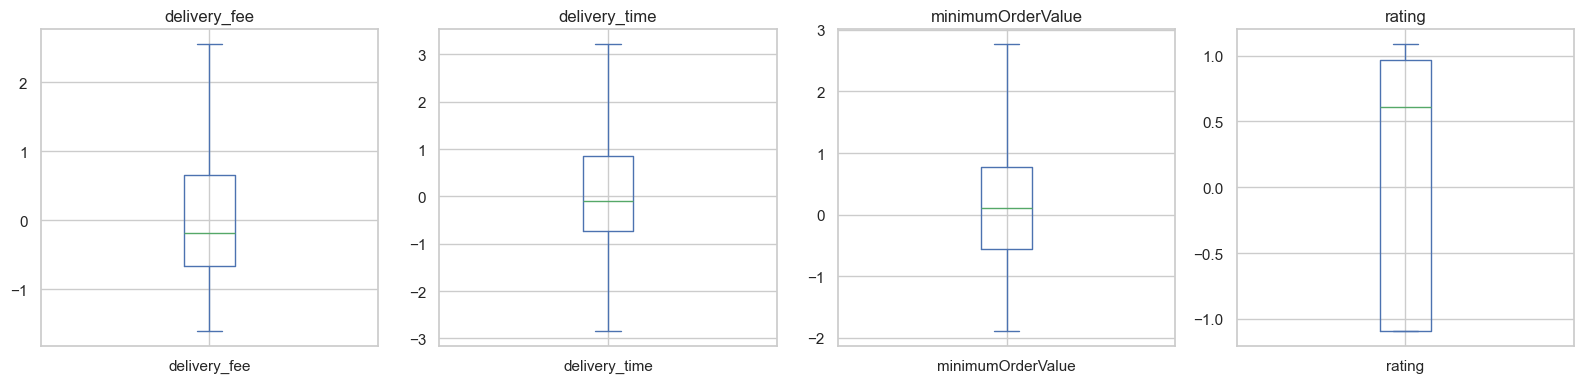

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, col_num):
    df[col].plot.box(ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

As correlações entre as variáveis numéricas são fracas (todas abaixo de 0,3). A mais forte é entre `delivery_fee` e `delivery_time` (positiva, ~0,2), e `delivery_time` tem uma leve correlação negativa com `rating`. Como Pearson e Spearman ficam próximos, as relações são praticamente lineares. No geral há pouca redundância entre as variáveis. Os histogramas e boxplots mostram as distribuições já padronizadas, com alguns valores extremos mesmo após a limpeza da Etapa 1. Nos próximos pontos da Etapa 2 vamos tratar a redução de redundância e a análise de componentes (PCA).

## 5. Feature Selection

Como as variáveis não apresentaram uma alta correlação, não há uma redundância clara a ser eliminada e não justifica o uso do PCA, faremos uma feature selection manual.

In [56]:
df_features = df.copy()
top_10_categorias = df['category'].value_counts().nlargest(10).index

# Primeiramente será removida a coluna 'availableForScheduling' pois é pouco relevante e com baixa representatividade no dataset (0,4% apenas).
df_features.drop(columns=['availableForScheduling'], inplace=True)
col_cat.remove('availableForScheduling')

# Agruparemos a coluna 'category' em categorias mais amplas para reduzir a cardinalidade e desbalanceamento. Se a categoria original estiver no top 10, mantém. Se não, vira 'Outros'
# Não faremos tratativas extras nessa coluna, ela será utilizada apenas para a analise final dos resultados, não será utilizada no treinamento do modelo.
df_features['category_grouped'] = df_features['category'].where(df_features['category'].isin(top_10_categorias), 'Outros')

# Vamos enumerar 'price_range' (Mapeamento Ordinal)
mapa_precos = {
    'CHEAPEST': 1,
    'CHEAP': 2,
    'MODERATE': 3,
    'EXPENSIVE': 4,
    'MOST_EXPENSIVE': 5
}
# O map substitui as strings pelos números correspondentes
df_features['price_encoded'] = df_features['price_range'].map(mapa_precos)

col_cat.remove('price_range')
col_cat.remove('category')

col_num.append('price_encoded')
col_cat.append('category_grouped')

df_features.drop(columns=['price_range', 'category'], inplace=True)

df_features.head(5)


,ibge,delivery_fee,delivery_time,minimumOrderValue,rating,category_grouped,price_encoded
0,5300108,-0.65929,-1.25145,-0.56250,-1.09434,Marmita,1
1,5300108,0.29218,0.92187,-0.56250,-1.09434,Açaí,1
2,5300108,1.24366,1.49716,-1.23009,-1.09434,Bebidas,3
3,5300108,2.31407,1.04971,0.77268,-1.09434,Outros,1
4,5300108,1.24366,0.73010,0.77268,-1.09434,Brasileira,1


## 6. UMAP

C:\Users\joaog\Pessoal\cd2-trabalho\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


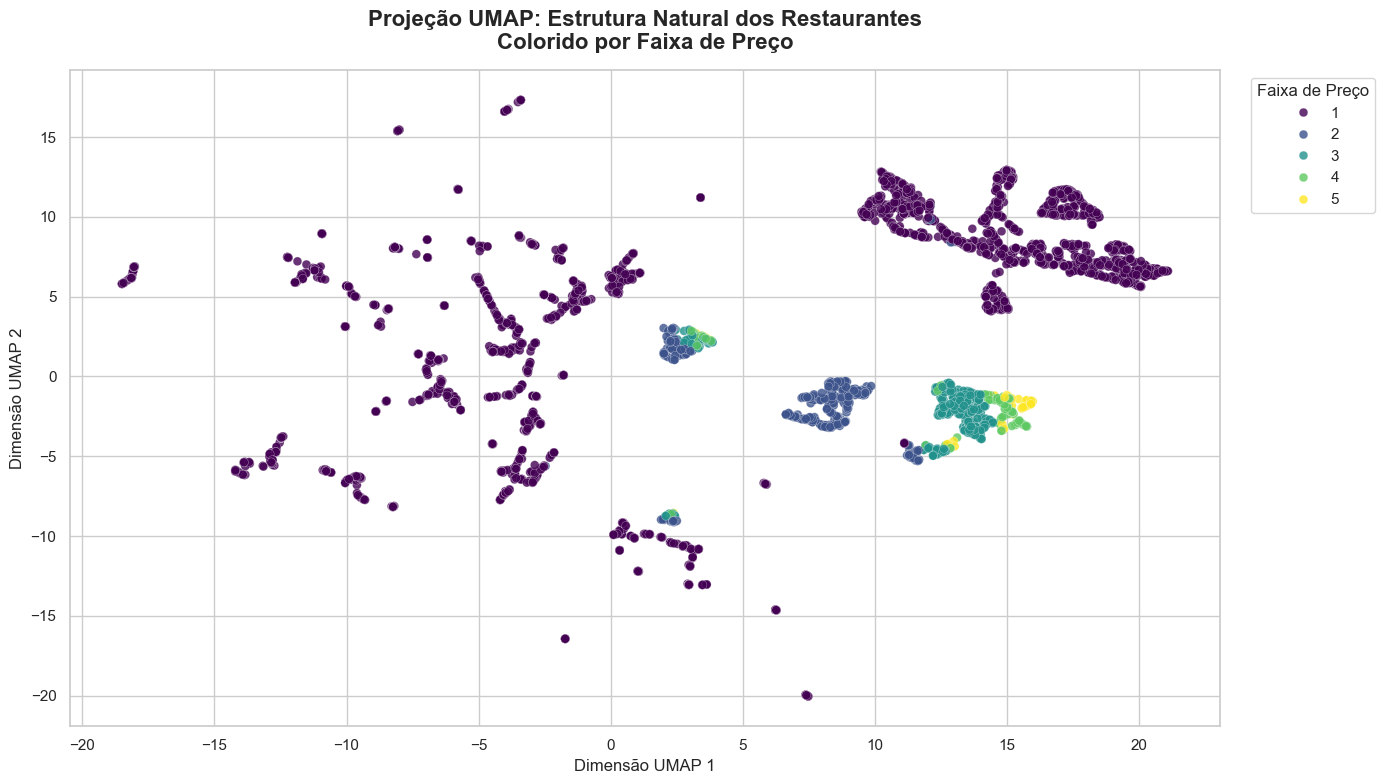

In [57]:
df_umap = df_features.dropna(subset=col_num).copy()

scaler = StandardScaler()
dados_escalados = scaler.fit_transform(df_umap[col_num])

# Rodaremos o UMAP em uma amostra aleatória com 5000 dados.
df_amostra, _, amostra_escalada, _ = train_test_split(
    df_umap,
    dados_escalados,
    train_size=5000,
    random_state=42
)

# Configurações do UMAP
redutor = umap.UMAP(n_components=2, metric='euclidean', random_state=42, n_neighbors=15, min_dist=0.1)
embedding_umap = redutor.fit_transform(amostra_escalada)

df_amostra['umap_x'] = embedding_umap[:, 0]
df_amostra['umap_y'] = embedding_umap[:, 1]

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

grafico = sns.scatterplot(
    data=df_amostra,
    x='umap_x',
    y='umap_y',
    hue='price_encoded',
    palette='viridis',
    s=40,
    alpha=0.8,
    edgecolor='w',
    linewidth=0.2
)

plt.title('Projeção UMAP: Estrutura Natural dos Restaurantes\nColorido por Faixa de Preço', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Dimensão UMAP 1', fontsize=12)
plt.ylabel('Dimensão UMAP 2', fontsize=12)


plt.legend(title='Faixa de Preço', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [58]:
df_numerico_escalado = pd.DataFrame(
    dados_escalados,
    columns=col_num,
    index=df_umap.index
)
df_categorico = df_umap[col_cat]

df_final = pd.concat([df_numerico_escalado, df_categorico], axis=1)
df_final.head(5)

output_path = _root / 'data' / 'processed' / 'restaurants_final.csv'
df_final.to_csv(output_path, index=False)
